# EQ/FX Conditional European: Calls, Puts × Above/Below Barrier

Pricing and risk for a vanilla equity payoff *gated* by an FX condition. The general payoff at maturity is:

$$ V_T = \max\!\big(\eta_S\,(S_T - K),\; 0\big) \cdot \mathbf{1}\{\eta_X\,(X_T - B) > 0\} $$

where $S$ = SPX, $X$ = USDJPY (JPY per USD), $K$ = equity strike, $B$ = FX barrier. The signs $\eta_S, \eta_X \in \{+1, -1\}$ select between four payoff variants:

| Variant | $\eta_S$ | $\eta_X$ | Payoff |
|---------|---------|---------|--------|
| Call × Above | +1 | +1 | $\max(S_T-K,0) \cdot \mathbf{1}\{X_T > B\}$ |
| Call × Below | +1 | -1 | $\max(S_T-K,0) \cdot \mathbf{1}\{X_T < B\}$ |
| Put × Above  | -1 | +1 | $\max(K-S_T,0) \cdot \mathbf{1}\{X_T > B\}$ |
| Put × Below  | -1 | -1 | $\max(K-S_T,0) \cdot \mathbf{1}\{X_T < B\}$ |

Each variant has a closed-form bivariate Black–Scholes price. The four prices are linked by the identity

$$V_{\text{above}} + V_{\text{below}} = V_{\text{vanilla}} \qquad \text{(call or put)}$$

since $\mathbf{1}\{X>B\} + \mathbf{1}\{X<B\} = 1$ a.s.

**Sections:**
1. Setup
2. Forwards under the model
3. Pricing the four variants (closed form + Monte Carlo)
4. Closed-form formula
5. Greeks across the four variants
6. Deep dive on call × X > B (delta, vega, FX vega, cega)
7. How variant choice flips the picture
8. Scenario walkthrough
9. Takeaways

## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from dataclasses import replace

from src.hybrid_pricer import HybridInputs, price_hybrid, price_hybrid_mc

In [2]:
# --- Trade attributes (defined inline, self-contained) ---
NOTIONAL = 100e6  # $100mm

p = HybridInputs(
    S0=7200.0,    # SPX spot
    X0=156.0,     # USDJPY spot (JPY per USD)
    K=7000.0,     # SPX strike
    B=160.0,      # USDJPY barrier
    T=0.5,        # 6 months
    r_d=0.045,    # USD rate (settlement currency, used for discounting)
    r_f=0.005,    # JPY rate (foreign side of USDJPY)
    q=0.015,      # SPX dividend yield
    sig_S=0.16,   # SPX vol
    sig_X=0.10,   # USDJPY vol
    rho=0.30,     # correlation between dW_S and dW_X under USD measure
)

print(f"Notional:    ${NOTIONAL/1e6:.0f}mm")
print(f"SPX:         spot {p.S0}, strike {p.K}  ({(p.S0/p.K-1)*100:+.1f}% relative to strike)")
print(f"USDJPY:      spot {p.X0}, barrier {p.B}  ({(p.B/p.X0-1)*100:+.1f}% from spot)")
print(f"Tenor:       {p.T}y")
print(f"Vols:        sig_S={p.sig_S:.0%}, sig_X={p.sig_X:.0%}")
print(f"Rates:       USD={p.r_d:.2%}, JPY={p.r_f:.2%}, SPX div q={p.q:.2%}")
print(f"Corr:        rho={p.rho}")

Notional:    $100mm
SPX:         spot 7200.0, strike 7000.0  (+2.9% relative to strike)
USDJPY:      spot 156.0, barrier 160.0  (+2.6% from spot)
Tenor:       0.5y
Vols:        sig_S=16%, sig_X=10%
Rates:       USD=4.50%, JPY=0.50%, SPX div q=1.50%
Corr:        rho=0.3


## 2. Forwards under the model

The pricer uses the **USD risk-neutral measure**. Under this measure:

$$dS/S = (r_{USD} - q)\,dt + \sigma_S\, dW^S$$
$$dX/X = (r_{JPY} - r_{USD} + \sigma_X^2)\,dt + \sigma_X\, dW^X$$

The $+\sigma_X^2$ on the FX drift is the **quanto convexity correction** from changing numeraire from JPY-cash to USD-cash via Itô on $1/X$. Under the JPY measure, USDJPY drifts at the textbook Garman–Kohlhagen rate $r_{JPY} - r_{USD}$.

Two FX forwards are worth distinguishing:

1. **Market FX forward** (CIP, model-free):
   $$F_X^{\text{mkt}} = X_0\, e^{(r_{JPY}-r_{USD})\,T}$$
   This is the rate at which a USDJPY forward actually trades.

2. **USD-measure expectation** (model-dependent):
   $$\mathbb{E}^{Q^{USD}}[X_T] = X_0\, e^{(r_{JPY}-r_{USD}+\sigma_X^2)\,T}$$
   This is what the pricer uses internally; it differs from the market forward by the $\sigma_X^2 T$ convexity bump.

For SPX, the forward is unambiguous because SPX settles in USD:
$$F_S(T) = S_0\, e^{(r_{USD}-q)\,T}$$

In [3]:
# --- Forwards at maturity ---
F_S      = p.S0 * np.exp((p.r_d - p.q) * p.T)                    # SPX forward
F_X_mkt  = p.X0 * np.exp((p.r_f - p.r_d) * p.T)                  # FX market fwd (CIP)
mu_X     = (p.r_f - p.r_d) + p.sig_X**2                           # USD-measure FX drift
F_X_usd  = p.X0 * np.exp(mu_X * p.T)                              # FX USD-measure expectation
quanto_bump = (np.exp(p.sig_X**2 * p.T) - 1) * 100                # %

print(f"Forwards at T = {p.T:.2f}y")
print()
print(f"  SPX (model-free):       F_S         = {F_S:8.2f}      ({(F_S/p.S0-1)*100:+.2f}% vs spot)")
print(f"  USDJPY market (CIP):    F_X_mkt     = {F_X_mkt:8.2f}      ({(F_X_mkt/p.X0-1)*100:+.2f}% vs spot)")
print(f"  USDJPY USD-measure:     E^Q^USD[X]  = {F_X_usd:8.2f}      ({(F_X_usd/p.X0-1)*100:+.2f}% vs spot)")
print()
print(f"  Quanto convexity bump:  exp(sig_X^2 * T) - 1 = {quanto_bump:+.4f}%")
print(f"  USD > JPY rate -> JPY forward-strengthens (negative carry on USD long)")
print()
print(f"  Strike vs SPX fwd:      K is {(p.K/F_S-1)*100:+.1f}% relative to F_S")
print(f"  Barrier vs market fwd:  B is {(p.B/F_X_mkt-1)*100:+.1f}% relative to F_X_mkt")

Forwards at T = 0.50y

  SPX (model-free):       F_S         =  7308.81      (+1.51% vs spot)
  USDJPY market (CIP):    F_X_mkt     =   152.91      (-1.98% vs spot)
  USDJPY USD-measure:     E^Q^USD[X]  =   153.68      (-1.49% vs spot)

  Quanto convexity bump:  exp(sig_X^2 * T) - 1 = +0.5013%
  USD > JPY rate -> JPY forward-strengthens (negative carry on USD long)

  Strike vs SPX fwd:      K is -4.2% relative to F_S
  Barrier vs market fwd:  B is +4.6% relative to F_X_mkt


**Read.** USD rates above JPY rates implies USDJPY forwards *below* spot — JPY is forward-strong. The barrier at 160 sits 1.0% above spot but ~3.0% above the market forward, so the FX leg starts already out-of-the-money in forward space. The quanto bump is small (50 bp) at this tenor and FX vol.

## 3. Pricing the four variants

In [4]:
# --- Closed-form prices for all 4 variants, with MC cross-check ---
units = NOTIONAL / p.S0

variants = [
    ("call", "above"),
    ("call", "below"),
    ("put",  "above"),
    ("put",  "below"),
]

print(f"{'Variant':<22} {'Closed form':>12} {'Premium':>11} {'MC est':>13} {'P(joint)':>10} {'P(FX)':>8}")
print("-" * 84)

results_e = {}
for eq, fx in variants:
    cf = price_hybrid(p, eq_type=eq, fx_dir=fx)
    mc = price_hybrid_mc(p, eq_type=eq, fx_dir=fx, n_paths=500_000, seed=42)
    results_e[(eq, fx)] = cf
    sign = ">" if fx == "above" else "<"
    label = f"{eq:>4}  x  X {sign} B"
    print(f"{label:<22} {cf['price']:>11.4f}    "
          f"${cf['price']*units/1e6:>6.2f}mm    "
          f"{mc['price']:>11.4f}     "
          f"{cf['P_joint_exercise']:>9.1%}  "
          f"{cf['P_FX_condition']:>7.1%}")

# Vanilla equivalents
v_call = results_e[("call", "above")]["vanilla_equivalent"]
v_put  = results_e[("put",  "above")]["vanilla_equivalent"]
print()
print(f"Vanilla SPX call:                    ${v_call*units/1e6:>6.2f}mm")
print(f"Vanilla SPX put:                     ${v_put*units/1e6:>6.2f}mm")

# Identity: above + below should equal the vanilla
sum_call = results_e[("call","above")]["price"] + results_e[("call","below")]["price"]
sum_put  = results_e[("put", "above")]["price"] + results_e[("put", "below")]["price"]
print()
print("Identity check (above + below = vanilla):")
print(f"  call_above + call_below = {sum_call:.6f}   vs  vanilla_call = {v_call:.6f}   diff = {sum_call - v_call:+.2e}")
print(f"  put_above  + put_below  = {sum_put:.6f}   vs  vanilla_put  = {v_put:.6f}   diff = {sum_put - v_put:+.2e}")

Variant                 Closed form     Premium        MC est   P(joint)    P(FX)
------------------------------------------------------------------------------------
call  x  X > B            190.4944    $  2.65mm       190.7184         20.8%    27.2%
call  x  X < B            298.7100    $  4.15mm       298.3472         42.0%    72.8%
 put  x  X > B             26.8692    $  0.37mm        26.8713          6.5%    27.2%
 put  x  X < B            160.3918    $  2.23mm       160.5803         30.8%    72.8%

Vanilla SPX call:                    $  6.79mm
Vanilla SPX put:                     $  2.60mm

Identity check (above + below = vanilla):
  call_above + call_below = 489.204409   vs  vanilla_call = 489.204409   diff = -1.82e-12
  put_above  + put_below  = 187.261074   vs  vanilla_put  = 187.261074   diff = -5.12e-13


**Read.** The barrier at 160 (above spot 156, USD weakening) is hard to reach in a USD-rates-high environment because the FX forward is *below* spot. So:

- `Call × Above` only pays in joint scenarios where SPX rallies *and* USDJPY rallies — only 16% of the risk-neutral mass.
- `Call × Below` is the cheap-FX version and captures most of the vanilla call premium.
- `Put × Above` is by far the cheapest leg — needs SPX to fall *and* JPY to weaken, which the model treats as anti-correlated to JPY-strength regimes.

The MC estimates match closed form to within 3 standard errors. The above + below identities zero out to floating-point precision.

## 4. Closed-form formula

The generalized pricer evaluates:

$$V_0 = \eta_S\, S_0\, e^{-qT}\, M_2\!\big(\eta_S\, d_1^S,\; \eta_X(d_2^X + \rho \sigma_S \sqrt{T});\; \eta_S\eta_X\,\rho\big)\; -\; \eta_S\, K\, e^{-r_{USD} T}\, M_2\!\big(\eta_S\, d_2^S,\; \eta_X\, d_2^X;\; \eta_S\eta_X\,\rho\big)$$

with

$$d_1^S = \frac{\ln(S_0/K) + (r_{USD} - q + \tfrac{1}{2}\sigma_S^2)T}{\sigma_S\sqrt{T}}, \quad d_2^S = d_1^S - \sigma_S\sqrt{T}$$

$$d_1^X = \frac{\ln(X_0/B) + (\mu_X + \tfrac{1}{2}\sigma_X^2)T}{\sigma_X\sqrt{T}}, \quad d_2^X = d_1^X - \sigma_X\sqrt{T}, \qquad \mu_X = r_{JPY} - r_{USD} + \sigma_X^2$$

The first term arises from a numeraire change to the equity asset; under that measure the FX log-mean shifts by $\rho\sigma_S\sqrt{T}$, hence the $+\rho\sigma_S\sqrt{T}$ in the FX argument. $M_2(\cdot,\cdot;\rho)$ is the standard bivariate normal CDF.

## 5. Greeks across the four variants

In [5]:
def greeks_for(p, eq_type, fx_dir):
    """Bump-and-revalue Greeks for the generalized hybrid."""
    base = price_hybrid(p, eq_type=eq_type, fx_dir=fx_dir)["price"]
    def bump(field, h):
        d = p.__dict__.copy(); d[field] = d[field] + h
        return price_hybrid(HybridInputs(**d), eq_type=eq_type, fx_dir=fx_dir)["price"]
    dS  = 0.01 * p.S0
    dX  = 0.01 * p.X0
    dv  = 0.01
    drho = 0.01
    return {
        "delta_SPX": (bump("S0", dS)  - bump("S0", -dS))  / (2*dS),
        "gamma_SPX": (bump("S0", dS)  - 2*base + bump("S0", -dS)) / (dS**2),
        "delta_FX":  (bump("X0", dX)  - bump("X0", -dX))  / 2,             # per +1% FX
        "vega_SPX":  (bump("sig_S", dv) - bump("sig_S", -dv)) / (2*dv) / 100,
        "vega_FX":   (bump("sig_X", dv) - bump("sig_X", -dv)) / (2*dv) / 100,
        "cega":      (bump("rho", drho) - bump("rho", -drho)) / (2*drho) / 100,
    }

print(f"{'Variant':<22} {'delta_S':>8} {'dV/d1%X':>9} {'vega_S $k':>10} {'vega_X $k':>10} {'cega $k':>9}")
print("-" * 73)
for eq, fx in variants:
    g = greeks_for(p, eq, fx)
    sign = ">" if fx == "above" else "<"
    label = f"{eq:>4}  x  X {sign} B"
    print(f"{label:<22} {g['delta_SPX']:>8.3f} {g['delta_FX']:>9.2f} "
          f"{g['vega_SPX']*units/1e3:>10.1f} "
          f"{g['vega_FX']*units/1e3:>10.1f} "
          f"{g['cega']*units/1e3:>9.1f}")

Variant                 delta_S   dV/d1%X  vega_S $k  vega_X $k   cega $k
-------------------------------------------------------------------------
call  x  X > B            0.224     27.05      111.3      181.5      28.1
call  x  X < B            0.440    -27.05      143.0     -181.5     -28.1
 put  x  X > B           -0.058      6.18       40.0       41.2      -9.9
 put  x  X < B           -0.271     -6.18      214.3      -41.2       9.9


**Observations:**

- **SPX delta** flips sign for puts (negative). For calls, it's smaller in the rare `Above` variant than in the more-likely `Below` variant.
- **FX vega flips sign with the barrier direction.** For `X > B`, more FX vol increases the chance of breach (positive vega). For `X < B`, more FX vol *reduces* the chance of staying below (negative vega).
- **Cega flips sign with $\eta_S \eta_X$.** When `eq` and `fx` directions agree, positive correlation helps. When they disagree, positive correlation hurts.

## 6. Deep dive: call × X > B

Helper functions for repeated re-pricing on grids.

In [6]:
def price_at(S0, X0, eq="call", fx="above", **ov):
    return price_hybrid(replace(p, S0=S0, X0=X0, **ov), eq_type=eq, fx_dir=fx)["price"]

def vega_at(S0, X0, which="sig_S", dv=0.01, eq="call", fx="above", **ov):
    up = price_at(S0, X0, eq=eq, fx=fx, **{**ov, which: getattr(p, which) + dv})
    dn = price_at(S0, X0, eq=eq, fx=fx, **{**ov, which: getattr(p, which) - dv})
    return (up - dn) / 2

def cega_at(S0, X0, drho=0.01, eq="call", fx="above", **ov):
    up = price_at(S0, X0, eq=eq, fx=fx, **{**ov, "rho": p.rho + drho})
    dn = price_at(S0, X0, eq=eq, fx=fx, **{**ov, "rho": p.rho - drho})
    return (up - dn) / 2

def delta_at(S0, X0, dS=None, eq="call", fx="above", **ov):
    dS = dS or 0.005 * p.K
    return (price_at(S0+dS, X0, eq=eq, fx=fx, **ov) - price_at(S0-dS, X0, eq=eq, fx=fx, **ov)) / (2*dS)

### SPX delta — well-behaved, but the *hedge size* depends on FX

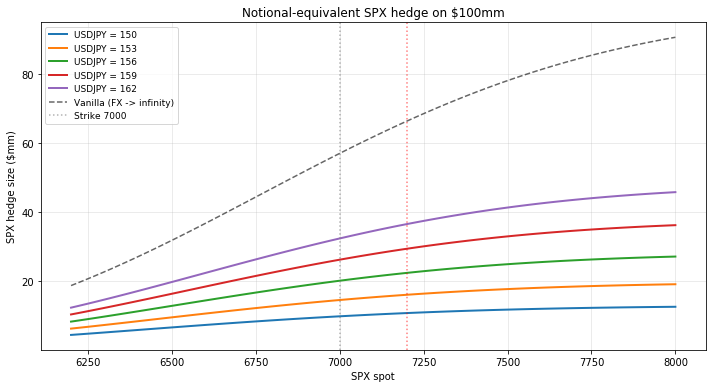

In [7]:
spx_grid = np.linspace(6200, 8000, 80)
fx_levels = [150, 153, 156, 159, 162]

fig, ax = plt.subplots(figsize=(10, 5.5))
for X0 in fx_levels:
    ne = [delta_at(s, X0) * NOTIONAL / 1e6 for s in spx_grid]
    ax.plot(spx_grid, ne, label=f"USDJPY = {X0}", linewidth=2)
vanilla_ne = [delta_at(s, 1000.0) * NOTIONAL / 1e6 for s in spx_grid]   # FX far above -> vanilla call
ax.plot(spx_grid, vanilla_ne, "k--", alpha=0.6, label="Vanilla (FX -> infinity)", linewidth=1.5)
ax.axvline(p.K, color="gray", ls=":", alpha=0.6, label=f"Strike {p.K:.0f}")
ax.axvline(p.S0, color="red", ls=":", alpha=0.5)
ax.set_xlabel("SPX spot"); ax.set_ylabel("SPX hedge size ($mm)")
ax.set_title(f"Notional-equivalent SPX hedge on ${NOTIONAL/1e6:.0f}mm")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Read.** Familiar S-curve, uniformly compressed by the FX-conditional probability. The hedge size on $100mm at-the-money ranges from ~$15mm (USDJPY=150) to ~$45mm (USDJPY=162) — a 6-yen FX move *triples* the SPX hedge requirement at the same SPX spot. That gap is the cross-gamma, baked into the static delta surface. The vanilla curve sits at the top: as USDJPY rises past the barrier, the hybrid delta rolls up toward the vanilla.

### FX delta — what the vanilla doesn't have

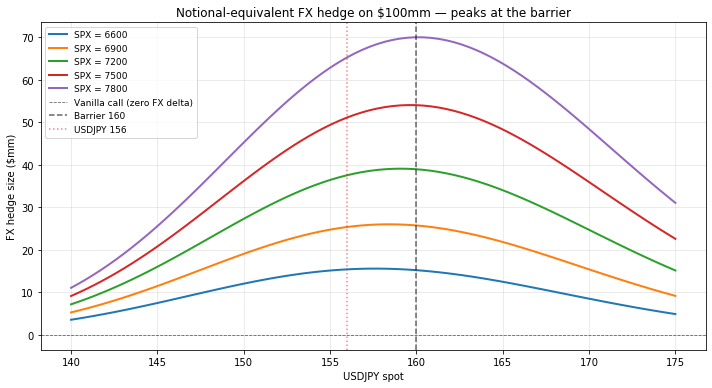

In [8]:
fx_grid = np.linspace(140, 175, 80)
spx_levels = [6600, 6900, 7200, 7500, 7800]

# FX delta as notional-equivalent FX hedge ($mm).
# (PnL per +1% FX move) * 100 = USD-notional of FX you'd need to short to hedge.
def fx_hedge_mm(S0, X0, eq="call", fx="above"):
    units_local = NOTIONAL / S0
    dX = 0.01 * X0
    pnl_per_1pct = (price_at(S0, X0+dX, eq=eq, fx=fx) - price_at(S0, X0-dX, eq=eq, fx=fx)) * units_local / 2
    return pnl_per_1pct * 100 / 1e6   # -> $mm notional-equivalent

fig, ax = plt.subplots(figsize=(10, 5.5))
for S0 in spx_levels:
    fxd = [fx_hedge_mm(S0, x) for x in fx_grid]
    ax.plot(fx_grid, fxd, label=f"SPX = {S0}", linewidth=2)
ax.axhline(0, color="black", linewidth=0.8, ls="--", alpha=0.6, label="Vanilla call (zero FX delta)")
ax.axvline(p.B, color="k", ls="--", alpha=0.6, label=f"Barrier {p.B:.0f}")
ax.axvline(p.X0, color="red", ls=":", alpha=0.5, label=f"USDJPY {p.X0:.0f}")
ax.set_xlabel("USDJPY spot"); ax.set_ylabel("FX hedge size ($mm)")
ax.set_title(f"Notional-equivalent FX hedge on ${NOTIONAL/1e6:.0f}mm — peaks at the barrier")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Read.** FX delta is zero for a vanilla SPX call — the dashed line at zero. The hybrid carries a notional-equivalent FX hedge of roughly $25–50mm on $100mm SPX notional at-the-money, peaking right at the barrier and rising further as SPX goes deeper ITM. This is the risk that often gets booked into the SPX desk and never delta-hedged — a half-the-book FX position hiding inside an equity option.

### SPX vega — bell-shaped, fanned by FX

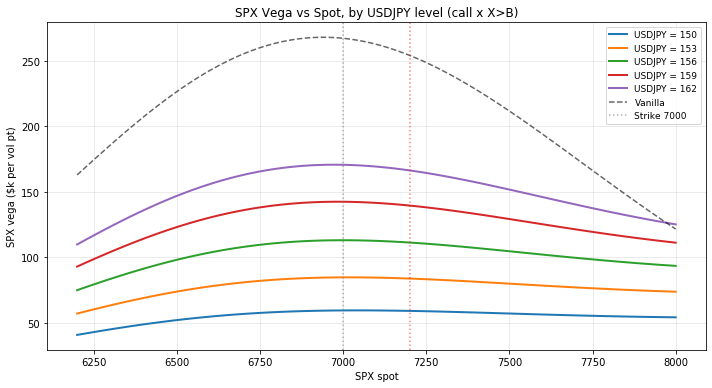

In [9]:
fig, ax = plt.subplots(figsize=(10, 5.5))
for X0 in fx_levels:
    vegas = [vega_at(s, X0, "sig_S") * units / 1e3 for s in spx_grid]
    ax.plot(spx_grid, vegas, label=f"USDJPY = {X0}", linewidth=2)
vanilla_v = [vega_at(s, 1000.0, "sig_S") * units / 1e3 for s in spx_grid]
ax.plot(spx_grid, vanilla_v, "k--", alpha=0.6, label="Vanilla", linewidth=1.5)
ax.axvline(p.K, color="gray", ls=":", alpha=0.6, label=f"Strike {p.K:.0f}")
ax.axvline(p.S0, color="red", ls=":", alpha=0.5)
ax.set_xlabel("SPX spot"); ax.set_ylabel("SPX vega ($k per vol pt)")
ax.set_title("SPX Vega vs Spot, by USDJPY level (call x X>B)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Read.** Standard call-vega bell, but the height depends on the FX level — cross-vega. SPX vega risk gets longer in JPY-weakening regimes, exactly when SPX vol is typically bid in risk-on episodes.

### FX vega — sign flips at the barrier

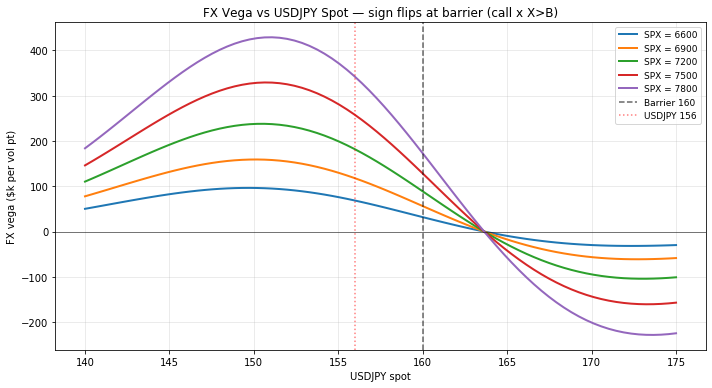

In [10]:
fx_grid = np.linspace(140, 175, 80)
spx_levels = [6600, 6900, 7200, 7500, 7800]

fig, ax = plt.subplots(figsize=(10, 5.5))
for S0 in spx_levels:
    fxv = [vega_at(S0, x, "sig_X") * units / 1e3 for x in fx_grid]
    ax.plot(fx_grid, fxv, label=f"SPX = {S0}", linewidth=2)
ax.axvline(p.B, color="k", ls="--", alpha=0.6, label=f"Barrier {p.B:.0f}")
ax.axvline(p.X0, color="red", ls=":", alpha=0.5, label=f"USDJPY {p.X0:.0f}")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("USDJPY spot"); ax.set_ylabel("FX vega ($k per vol pt)")
ax.set_title("FX Vega vs USDJPY Spot — sign flips at barrier (call x X>B)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Read.** The FX leg is a digital. Below the barrier, you *want* volatility (more chance of breach -> positive vega). Above, vol is your enemy. At the barrier, vega is exactly zero. To hedge a position whose vega flips sign, you need a **risk reversal centered at the barrier** — itself correlation-sensitive.

### Cega — correlation risk

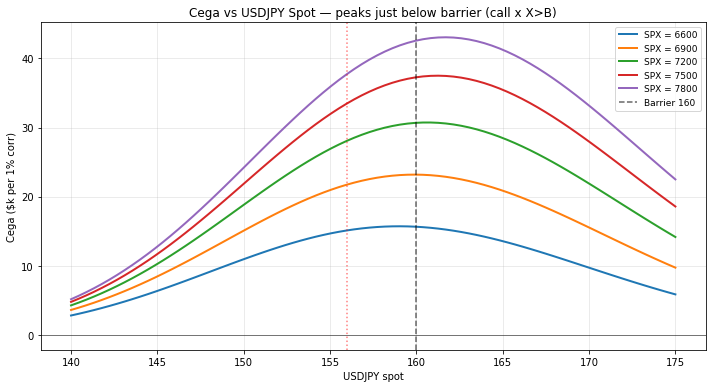

In [11]:
fig, ax = plt.subplots(figsize=(10, 5.5))
for S0 in spx_levels:
    cs = [cega_at(S0, x) * units / 1e3 for x in fx_grid]
    ax.plot(fx_grid, cs, label=f"SPX = {S0}", linewidth=2)
ax.axvline(p.B, color="k", ls="--", alpha=0.6, label=f"Barrier {p.B:.0f}")
ax.axvline(p.X0, color="red", ls=":", alpha=0.5)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("USDJPY spot"); ax.set_ylabel("Cega ($k per 1% corr)")
ax.set_title("Cega vs USDJPY Spot — peaks just below barrier (call x X>B)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Read.** Cega bell-shapes around the barrier. At extremes the FX leg becomes deterministic and correlation no longer matters. At spot, cega is near peak — the trade sits at maximum correlation risk per dollar of premium. This is the unhedgeable risk: you can hedge SPX delta and FX delta, but you can't directly hedge $\rho$.

## 7. How variant choice flips the picture

FX vega for `call × above` and `call × below` mirror each other across the barrier. Same is true for cega.

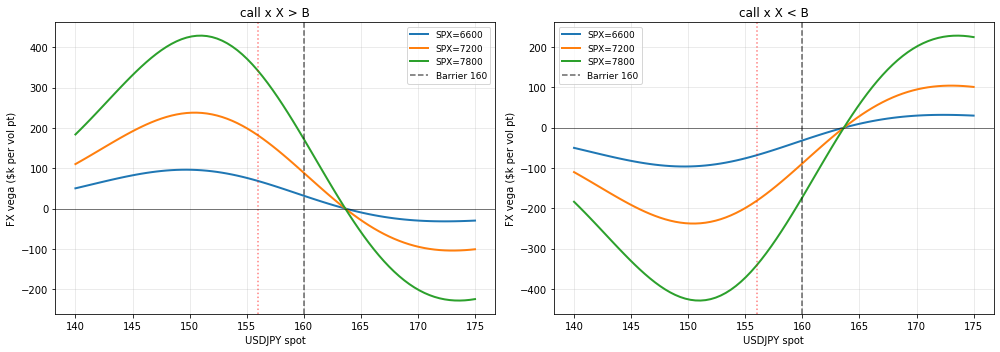

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, fx_dir in zip(axes, ["above", "below"]):
    for S0 in [6600, 7200, 7800]:
        v = [vega_at(S0, x, "sig_X", eq="call", fx=fx_dir) * units / 1e3 for x in fx_grid]
        ax.plot(fx_grid, v, label=f"SPX={S0}", linewidth=2)
    ax.axvline(p.B, color="k", ls="--", alpha=0.6, label=f"Barrier {p.B:.0f}")
    ax.axvline(p.X0, color="red", ls=":", alpha=0.5)
    ax.axhline(0, color="black", linewidth=0.5)
    sign = ">" if fx_dir == "above" else "<"
    ax.set_xlabel("USDJPY spot"); ax.set_ylabel("FX vega ($k per vol pt)")
    ax.set_title(f"call x X {sign} B")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Read.** Mirror image. For `X < B`, vol *helps* until you cross the barrier, then hurts — opposite of `X > B`. Sum of the two FX vega curves at any (S, X) is the vanilla call's *zero* FX vega (vanilla doesn't depend on FX vol).

## 8. Scenario walkthrough — call × X > B, deep ITM, delta-hedged, FX shock

The classic pathology of EQ/FX hybrids. You think you're risk-neutral on SPX. You aren't.

**State 0:** SPX = 7600 (deep ITM), USDJPY = 162 (FX leg ITM), SPX delta-hedged statically.

**Shock:** USDJPY drops 6 yen to 156 — a single liquid trading day in the pair.

In [13]:
S0_init, X0_init = 7600.0, 162.0
P0 = price_at(S0_init, X0_init)
D0 = delta_at(S0_init, X0_init)
units0 = NOTIONAL / S0_init
hedge_units = D0 * units0
opt0 = P0 * units0

print(f"State 0:")
print(f"  Option MTM:    ${opt0/1e6:.2f}mm")
print(f"  SPX delta:     {D0:.3f}")
print(f"  Hedge:         short {hedge_units:,.0f} SPX = ${hedge_units*S0_init/1e6:.2f}mm")
print()

scenarios = [
    ("(a) FX -6, SPX flat", S0_init,        156.0),
    ("(b) FX -6, SPX -2%",  S0_init * 0.98, 156.0),
    ("(c) FX -6, SPX -4%",  S0_init * 0.96, 156.0),
]

print(f"{'Scenario':<24}{'OptPnL':>10}{'HedgePnL':>11}{'NetPnL':>10}")
print("-" * 56)
for name, S1, X1 in scenarios:
    opt_pnl = (price_at(S1, X1) - P0) * units0
    hedge_pnl = hedge_units * (S0_init - S1)
    net = opt_pnl + hedge_pnl
    print(f"{name:<24}{opt_pnl/1e6:>+10.3f}{hedge_pnl/1e6:>+11.3f}{net/1e6:>+10.3f}")

State 0:
  Option MTM:    $5.99mm
  SPX delta:     0.426
  Hedge:         short 5,602 SPX = $42.57mm

Scenario                    OptPnL   HedgePnL    NetPnL
--------------------------------------------------------
(a) FX -6, SPX flat         -2.212     +0.000    -2.212
(b) FX -6, SPX -2%          -2.713     +0.851    -1.862
(c) FX -6, SPX -4%          -3.193     +1.703    -1.490


On a 6-yen FX move with SPX flat, the trade loses ~$2mm — about 26% of MTM — despite a perfect SPX delta hedge. The 2D PnL surface below shows a steep tilt: the hedge captures SPX risk but leaves FX exposure naked.

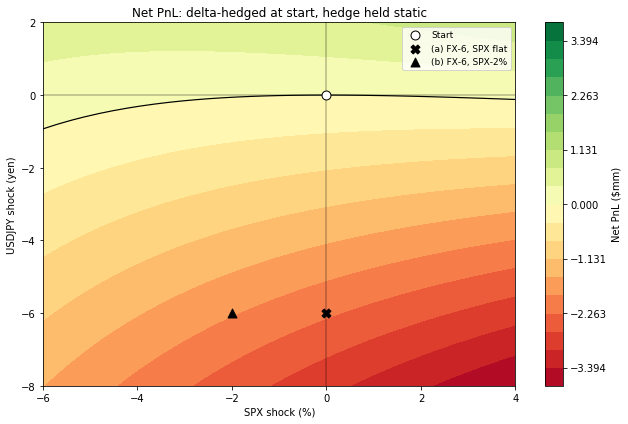

In [14]:
spx_shocks = np.linspace(-0.06, 0.04, 35)
fx_shocks = np.linspace(-8, 2, 35)
PNL = np.zeros((len(fx_shocks), len(spx_shocks)))
for i, dx in enumerate(fx_shocks):
    for j, ds in enumerate(spx_shocks):
        S1 = S0_init * (1 + ds); X1 = X0_init + dx
        opt_pnl = (price_at(S1, X1) - P0) * units0
        hedge_pnl = hedge_units * (S0_init - S1)
        PNL[i, j] = (opt_pnl + hedge_pnl) / 1e6

fig, ax = plt.subplots(figsize=(9, 6))
vmax = np.abs(PNL).max()
cf = ax.contourf(spx_shocks * 100, fx_shocks, PNL,
                 levels=np.linspace(-vmax, vmax, 21), cmap="RdYlGn")
ax.contour(spx_shocks * 100, fx_shocks, PNL, levels=[0], colors="black", linewidths=1.2)
plt.colorbar(cf, ax=ax, label="Net PnL ($mm)")
ax.scatter([0], [0], color="white", edgecolor="black", s=80, zorder=5, label="Start")
ax.scatter([0], [-6], color="black", s=80, marker="X", zorder=5, label="(a) FX-6, SPX flat")
ax.scatter([-2], [-6], color="black", s=80, marker="^", zorder=5, label="(b) FX-6, SPX-2%")
ax.set_xlabel("SPX shock (%)"); ax.set_ylabel("USDJPY shock (yen)")
ax.set_title("Net PnL: delta-hedged at start, hedge held static")
ax.legend(loc="upper right", fontsize=9)
ax.axhline(0, color="black", linewidth=0.4); ax.axvline(0, color="black", linewidth=0.4)
plt.tight_layout(); plt.show()

## 9. Takeaways

1. **All four variants share one closed form.** Once you generalize to $\eta_S, \eta_X$ signs, calls/puts and above/below collapse into the same Heynen–Kat bivariate-BS structure.

2. **Identities:** `above + below = vanilla`. Useful sanity check, and a way to price one variant from the others.

3. **FX vega and cega flip sign with $\eta_X$.** The sign of correlation risk depends on whether the equity payoff and FX condition agree directionally.

4. **SPX delta hedging gives false comfort.** Three independent risks (SPX, FX, correlation); hedging one doesn't help when the others move.

5. **For real desk marks**, layer on SPX skew, FX skew, correlation skew, and stochastic vol. This bivariate BS is the benchmark, not the production mark.